# Part 2 — Uncertainty and true talent

Part 1 ended at a wall. With the information available, v0's *point estimate* cannot get better at predicting what a hitter does next — it's at Savant's ceiling, and even a decisively better surface (spray at matched capacity) didn't move that. So if the point estimate is capped, the value has to come from somewhere else.

Two places, and they turn out to be the same place approached from different ends:

- **How sure are we** about a hitter's number, given how few plate appearances it's built on?
- **What is his true talent** underneath the noise in that number?

The first is a question about the *band* around the estimate; the second is a question about its *center*. This part builds three layers, each fixing the previous one's weakness — the right band (`results/task_a/`, `results/player_ci/`), then a sample-size-honest center (`results/talent/`), then a better prior for that center (`results/talent2/`).

None of this re-fits BART. Everything downstream of the surface runs closed-form off public Savant per-event values, in seconds.

In [1]:
# --- setup: locate the repo and import the shared notebook helpers (run this first) ---
import sys
from pathlib import Path

_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.yaml").exists()), Path.cwd())
sys.path.insert(0, str(_root / "notebooks"))
from nb_helpers import ROOT, RESULTS, jload, show_fig

import polars as pl
from IPython.display import Markdown, display

print("repo root:", ROOT)
print("results:  ", RESULTS, "(exists)" if RESULTS.exists() else "(MISSING)")

repo root: /Users/jweinga/Documents/python/xwobart
results:   /Users/jweinga/Documents/python/xwobart/results (exists)


In [2]:
# the artifacts this notebook reads
ta = jload("task_a/task_a_metrics.json")        # v0's own posterior interval, examined
ci = jload("player_ci/ci_metrics.json")         # a bootstrap over each player's PAs
tm = jload("talent/talent_metrics.json")        # Phase 1: empirical-Bayes true talent
m2 = jload("talent2/talent2_metrics.json")      # Level 2: joint MVN with peripherals
l2a, l2b = m2["l2a"], m2["l2b"]                 # l2a = the reproduce-Phase-1 gate, l2b = the real thing
H = l2b["hypers"]

print("loaded:", ", ".join(["task_a", "player_ci", "talent", "talent2"]))

loaded: task_a, player_ci, talent, talent2


## 1. "How sure are we" is really two questions

It sounds like one question, but it points at two completely different objects, and I ran into that the hard way.

1. **The BART posterior interval.** This is v0's built-in uncertainty. It measures how uncertain the *model* is about the xwOBA surface at a given contact profile — not how much data we have on the player.
2. **A bootstrap over each player's own plate appearances.** This one behaves the way you'd want: it narrows as PA grows, like an honest confidence interval should.

If the BART interval were a real "how sure are we" band, it would get tighter for players with more plate appearances. Let me check whether it does.

In [3]:
pl.DataFrame([
    {"quantity": "player-seasons analysed",    "value": f"{ta['n_player_seasons']:,}",
     "how to read it": f"median {ta['median_pa']:.0f} PA"},
    {"quantity": "median 90% interval width",  "value": f"{ta['median_width']:.4f}",
     "how to read it": "in wOBA points"},
    {"quantity": "log(width) ~ log(PA) slope", "value": f"{ta['width_vs_pa_loglog']['slope']:+.3f}",
     "how to read it": "an honest sampling band would be near -0.5; ~0 means flat"},
    {"quantity": "width <-> PA correlation",   "value": f"{ta['width_r_pa']:+.3f}",
     "how to read it": "mildly positive — an honest band would be strongly negative"},
    {"quantity": "width <-> xwOBA correlation","value": f"{ta['width_r_xwoba_mean']:+.3f}",
     "how to read it": "the band tracks the contact profile instead of the sample size"},
    {"quantity": "Savant inside the 90% band", "value": f"{ta['savant_in_ci90_fraction']:.1%}",
     "how to read it": "so it IS a real band — just a band about the surface, not the player"},
])

quantity,value,how to read it
"""player-seasons analysed""","""1,829""","""median 363 PA"""
"""median 90% interval width""","""0.0577""","""in wOBA points"""
"""log(width) ~ log(PA) slope""","""+0.049""","""an honest sampling band would …"
"""width <-> PA correlation""","""+0.223""","""mildly positive — an honest ba…"
"""width <-> xwOBA correlation""","""+0.393""","""the band tracks the contact pr…"
"""Savant inside the 90% band""","""94.4%""","""so it IS a real band — just a …"


Flat, and if anything faintly *increasing* in PA. The model's band is about as wide for a 100-PA player as for a 600-PA one, and it correlates more with the hitter's contact profile than with his sample size. That's a coherent object — it's just not the one the question asked for.

So build the right one: resample each player's own plate appearances and read the spread off the bootstrap. If that's a genuine sampling band, its width should fall off roughly like 1/√PA.

In [4]:
print("log(width) ~ log(PA) slope:", round(ci["loglog_slope_width_vs_pa"]["slope"], 3), " (near the ideal -0.5)")
print("bootstrap width vs analytic SE:  r =", round(ci["corr_bootstrap_width_vs_analytic_se"], 3), " (a genuine sampling band)")
pl.DataFrame([{"PA (bin midpoint)": db["pa_mid"],
               "bootstrap width": round(db["median"], 3),
               "v0 model width": round(dm["median"], 3),
               "ratio": round(db["median"] / dm["median"], 2)}
              for db, dm in zip(ci["bootstrap_width_bin_medians"], ci["model_width_bin_medians"])])

log(width) ~ log(PA) slope: -0.422  (near the ideal -0.5)
bootstrap width vs analytic SE:  r = 0.994  (a genuine sampling band)


PA (bin midpoint),bootstrap width,v0 model width,ratio
121.0,0.102,0.056,1.8
172.0,0.085,0.057,1.51
247.0,0.073,0.057,1.29
346.0,0.062,0.057,1.08
446.5,0.058,0.057,1.01
596.0,0.051,0.06,0.86


**What to look for:** the blue bootstrap curve falling like a real confidence interval while the orange model band sits flat — and the point where they cross.

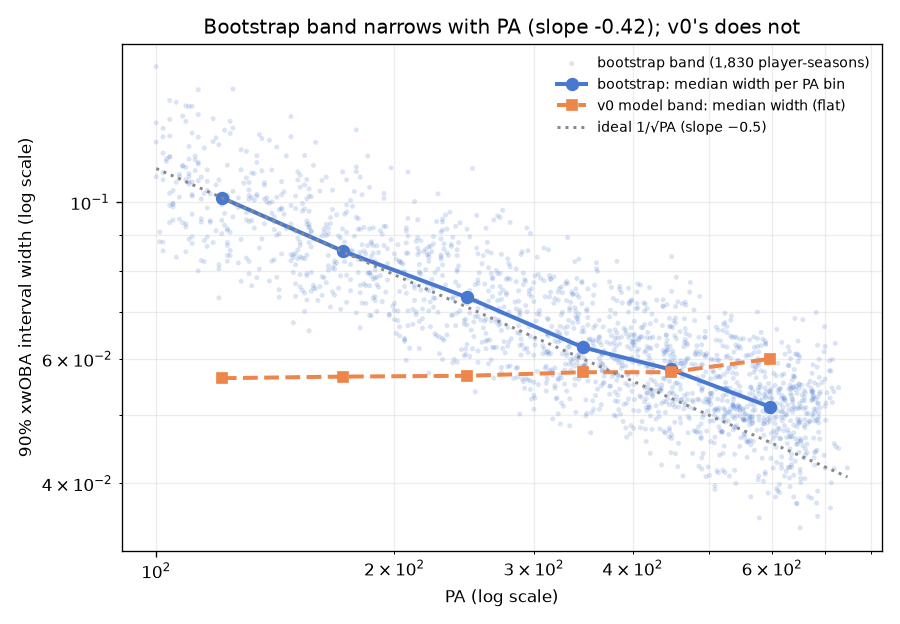

*Median band width by PA bin: the bootstrap falls like a real confidence interval; the model band stays flat.*

In [5]:
show_fig("player_ci/figures/width_vs_pa_bootstrap_vs_model.png",
         caption="Median band width by PA bin: the bootstrap falls like a real confidence interval; the model band stays flat.")

The two cross somewhere between 450 and 600 PA. Below that, v0's flat interval is too narrow — at the lowest bin (midpoint 121 PA) the honest band is **0.102** wide against the model's **0.056**, a factor of **1.8**. It understates uncertainty precisely in the small-sample regime where you care about it most.

**What to look for:** the blue bootstrap band swelling as PA falls down the rows, while the orange model band barely reacts.

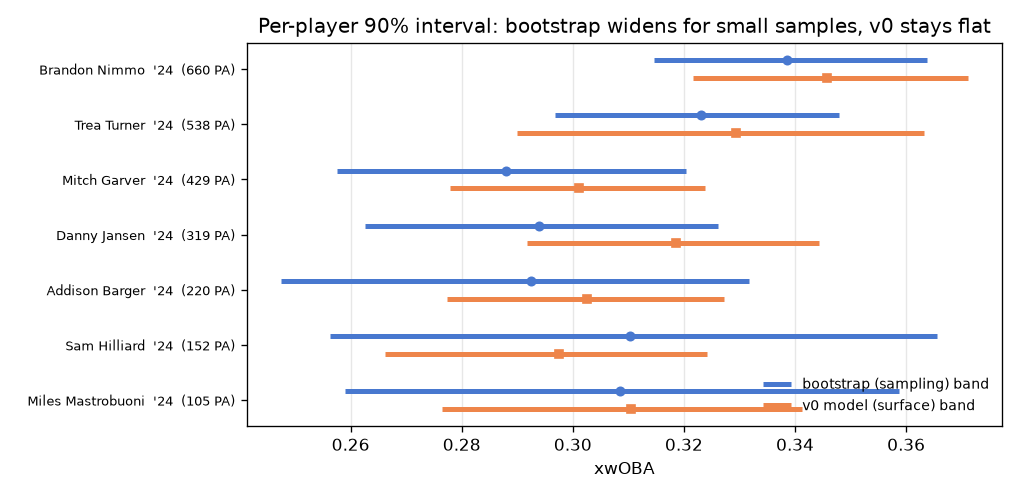

*Per-player 90% bands for seven 2024 hitters, most PA at the top: the bootstrap (blue) widens for small samples; the v0 surface band (orange) stays about the same.*

In [6]:
show_fig("player_ci/figures/example_player_bands.png",
         caption="Per-player 90% bands for seven 2024 hitters, most PA at the top: the bootstrap (blue) widens for small samples; the v0 surface band (orange) stays about the same.")

So the right band comes from resampling a player's PAs, not from BART. But there's a catch that sets up everything below: **that band is centered on the player's raw number**, so it still over-credits a hitter who got hot in 60 PA. Widening the interval around a wrong center doesn't fix the center.

## 2. The center: true-talent xwOBA by empirical Bayes

This is the object I actually wanted — a number for *analyzing a hitter*. For each batter-season, an xwOBA **regressed for sample size** (a scorching 120-PA line gets pulled back toward the league until the plate appearances justify it), paired with an interval that narrows as PA grows.

The method is deliberately simple: Gaussian–Gaussian empirical Bayes, no BART re-fit.

`theta_hat = mu + reliability * (raw - mu)`,  where  `reliability = tau^2 / (tau^2 + se^2)`

In words: start at the league mean `mu` and move toward the player's raw number only as far as the reliability of his sample allows. The two knobs are fit separately per season on players with 100+ PA, then applied to everyone.

In [7]:
pl.DataFrame([
    {"season": r["season"], "n": r["n"], "mu (league)": round(r["mu"], 4),
     "tau (spread)": round(r["tau"], 4), "median reliability": round(r["median_reliability"], 3)}
    for r in tm["per_season"]
])

season,n,mu (league),tau (spread),median reliability
2022,678,0.3046,0.0312,0.645
2023,647,0.3142,0.0308,0.643
2024,645,0.3103,0.0307,0.654
2025,666,0.3179,0.0323,0.648


**What to look for:** the grey raw numbers scattering wildly at the left of the log-PA axis while the blue talent estimates hug the dashed season mean, the two converging as PA grows.

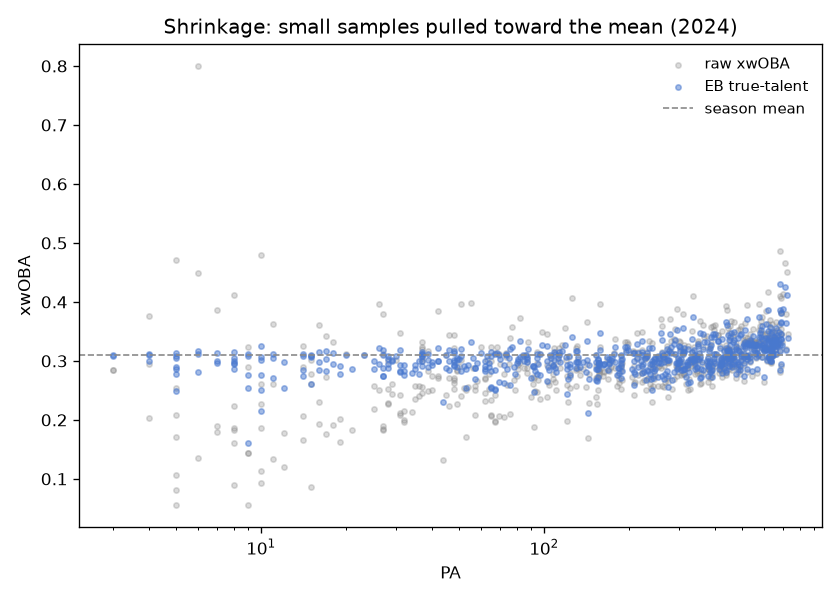

*2024 player-seasons on a log-PA axis: raw xwOBA (grey) scatters wildly at low PA; the talent estimate (blue) hugs the dashed season mean until the sample earns a gap.*

In [8]:
show_fig("talent/figures/shrinkage_raw_to_talent.png",
         caption="2024 player-seasons on a log-PA axis: raw xwOBA (grey) scatters wildly at low PA; the talent estimate (blue) hugs the dashed season mean until the sample earns a gap.")

The dial doing that work is **reliability** — the share of the raw number the estimator keeps. **What to look for:** a steep climb through the first 100 PA (about 0.5 there), levelling near 0.8 for everyday players — and the stray points pinned at **1.0 on the far left**. Those are tiny samples whose outcomes happened not to vary at all, so the estimator concludes they are perfectly measured. Hold that thought; it's a real bug and §3 fixes it.

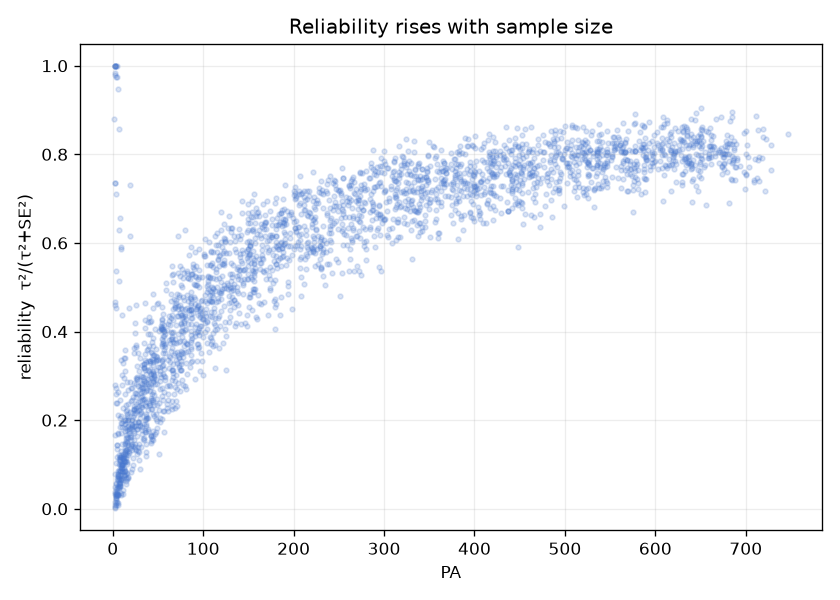

*Reliability tau^2/(tau^2+SE^2) vs PA — ~0.5 near 100 PA, ~0.8 by 500. The 1.0s at far left are zero-variance small samples.*

In [9]:
show_fig("talent/figures/reliability_vs_pa.png",
         caption="Reliability tau^2/(tau^2+SE^2) vs PA — ~0.5 near 100 PA, ~0.8 by 500. The 1.0s at far left are zero-variance small samples.")

Abstractions are easier to trust with names attached, so here are three hitters run through the estimator.

In [10]:
t = pl.read_parquet(RESULTS / "talent" / "talent_table.parquet")
def ex(name, season):
    r = t.filter((pl.col("player_name") == name) & (pl.col("season") == season)).row(0, named=True)
    return {"player": name, "season": season, "PA": r["PA"],
            "raw": round(r["xwoba_raw"], 3), "talent": round(r["xwoba_talent"], 3),
            "90% lo": round(r["talent_lo"], 3), "90% hi": round(r["talent_hi"], 3),
            "reliability": round(r["reliability"], 3)}
pl.DataFrame([
    ex("Khalil Lee", 2022),     # 2 PA, extreme hot -> fully regressed to league
    ex("Mike Trout", 2024),     # 125 PA, hot -> pulled down to a believable .341
    ex("Austin Hedges", 2024),  # 143 PA, cold, low-variance -> pulled up
])

player,season,PA,raw,talent,90% lo,90% hi,reliability
"""Khalil Lee""",2022,2,0.911,0.305,0.254,0.357,0.001
"""Mike Trout""",2024,125,0.407,0.341,0.299,0.383,0.313
"""Austin Hedges""",2024,143,0.168,0.212,0.184,0.24,0.695


Worth pausing on Trout: he gets regressed *harder* than Hedges at a similar PA count. Not a bug — the estimator leans on each player's own noisiness (Trout's boom-or-bust, high per-PA variance) rather than just counting plate appearances.

Fancy method, fine. Does regressing for sample size actually predict next season better than the raw number, or than Savant?

In [11]:
v = tm["validation"]
def row(label, block):
    return {"population": label, "n": block["n"],
            "EB talent r": round(block["xwoba_talent"]["r"], 4),
            "raw r": round(block["xwoba_raw"]["r"], 4),
            "Savant r": round(block["xwoba_savant"]["r"], 4)}
pl.DataFrame([
    row("pooled, PA_T >= 100 (vs the 0.487 anchor)", v["pooled_pa_min"]),
    row("pooled, PA_T >= 30 (admits low-PA)", v["pooled_lowpa_inclusive"]),
])

population,n,EB talent r,raw r,Savant r
"""pooled, PA_T >= 100 (vs the 0.…",1060,0.4886,0.4835,0.4908
"""pooled, PA_T >= 30 (admits low…",1173,0.4669,0.4454,0.4521


EB talent beats the raw number in both populations, and it **beats Savant once genuinely low-PA seasons are admitted** — 0.467 vs 0.452. At the 100+ PA anchor it ties Savant (0.489 vs 0.491): the same parity as Part 1, except the *center* is now sample-size-honest.

One subtlety that looks like a bug and isn't. Inside a narrow PA band, reliability is nearly constant, so `theta_hat = mu(1-c) + c*raw` is essentially **affine** in the raw number — and Pearson r is blind to affine transforms. Per-band r therefore *can't* move much no matter how good the shrinkage is; those tiny per-band gaps are noise. Shrinkage pays off across a *heterogeneous*-PA population, by compressing the wild low-PA raw numbers, and that only shows up pooled.

In [12]:
pl.DataFrame([
    {"PA band": b["band"], "n": b["n"], "median reliability": round(b["median_reliability"], 2),
     "|talent-raw|": round(b["mean_abs_talent_minus_raw"], 4),
     "talent r": round(b["xwoba_talent"]["r"], 3), "raw r": round(b["xwoba_raw"]["r"], 3),
     "savant r": round(b["xwoba_savant"]["r"], 3)}
    for b in v["by_band"]
])

PA band,n,median reliability,|talent-raw|,talent r,raw r,savant r
"""[30,60)""",50,0.27,0.0409,0.239,0.209,0.211
"""[60,100)""",63,0.39,0.0186,0.088,0.11,0.128
"""[100,250)""",227,0.57,0.013,0.277,0.278,0.293
"""[250,inf)""",833,0.77,0.0069,0.512,0.516,0.523


## 3. The prior: shrinking toward what the contact says

There's an obvious weakness in all of that: every player is shrunk toward the **league mean**, which is the honest answer when you know nothing else about him — but you *do* know something else. You know how hard he hits the ball.

That matters because exit velocity and barrel rate settle down much faster than xwOBA. At 40 plate appearances a hitter's xwOBA is still mostly noise while his average exit velocity is already saying something real; in the 30–100 PA range the peripherals predict next season **better than raw xwOBA does** (barrel rate r 0.244, exit velo 0.227, raw xwOBA 0.179). So they belong in the prior.

(The version I tried first — shrink toward the BART model's own xwOBA — went nowhere, and it's worth knowing why: the surface is built from the *same batted balls* as the raw number, so once you decompose it there's essentially no residual spread left to shrink toward. A structural no-op, not a tuning failure.)

Rather than *regressing* xwOBA on the peripherals, all three stats are treated as **noisy measurements of correlated talents**:

- what we measure: `z = (xwOBA, avg EV, barrel rate)` ~ `N(true talents, S_i)`
- what's true:     `(theta, xi)` ~ `N(mu_season, Sigma_talent)`
- what we want:    `theta_hat = mu + Sigma (Sigma + S_i)^-1 (z - mu)`

`S_i` is how badly *this* hitter's three numbers are measured, bootstrapped from his own plate appearances. `Sigma_talent` is how the three talents co-vary across the league. Closed-form, ~7 seconds. Stare at that last line: when `S_i` is large (small sample) the estimate leans on `mu` and on what the *other two* stats imply; when `S_i` is small it leans on the hitter's own xwOBA. The peripherals get a vote exactly where xwOBA can't be trusted.

In [13]:
import numpy as np
dims = ["xwOBA", "avg EV", "barrel rate"]
C = l2b["sigma_talent_corr"]
display(pl.DataFrame({"talent corr": dims,
                      **{d: [round(C[i][j], 3) for i in range(3)] for j, d in enumerate(dims)}}))
sd = np.sqrt(np.diag(np.array(H["Sigma"])))
pl.DataFrame([{"talent SD — xwOBA": round(float(sd[0]), 4),
               "talent SD — avg EV (mph)": round(float(sd[1]), 2),
               "talent SD — barrel rate": round(float(sd[2]), 4)}])

talent corr,xwOBA,avg EV,barrel rate
"""xwOBA""",1.0,0.776,0.712
"""avg EV""",0.776,1.0,0.824
"""barrel rate""",0.712,0.824,1.0


talent SD — xwOBA,talent SD — avg EV (mph),talent SD — barrel rate
0.0312,2.42,0.0367


Strongly and positively correlated, which is what baseball would tell you: hitters who square the ball up have higher xwOBA talent (+0.78 with exit velo, +0.71 with barrel rate). Those correlations *are* the mechanism — they're what lets a good exit-velo reading pull an xwOBA estimate upward.

And the sanity check that mattered most to me: a completely different estimator, fit a completely different way (marginal MLE rather than method-of-moments), lands an xwOBA talent SD of **0.0312** — right inside §2's per-season τ range of 0.0307–0.0323. That passed before I looked at a single validation number.

Here's what it does to actual hitters. Low-PA seasons where the contact quality **disagrees** with the results; `next` is the following season's actual wOBA, which neither model got to see.

In [14]:
t2 = pl.read_parquet(RESULTS / "talent2" / "talent2_table.parquet")
def ex2(name, season, note):
    d = t2.filter((pl.col("player_name") == name) & (pl.col("season") == season))
    assert d.height == 1, f"expected 1 row for {name} {season}, got {d.height}"
    r = d.row(0, named=True)
    return {"player": name, "season": season, "PA": r["PA"],
            "EV": round(r["avg_ev"], 1), "barrel": round(r["barrel_rate"], 3),
            "raw": round(r["xwoba_raw"], 3), "Phase 1": round(r["xwoba_talent"], 3),
            "Level 2": round(r["xwoba_talent2"], 3), "next": round(r["actual_woba"], 3), "": note}
pl.DataFrame([
    ex2("Sal Stewart", 2025,    "hot line, elite contact"),
    ex2("Stone Garrett", 2022,  "average line, good contact"),
    ex2("Tyler Heineman", 2023, "hot line, no contact"),
    ex2("César Salazar", 2024,  "<- a miss"),
])

player,season,PA,EV,barrel,raw,Phase 1,Level 2,next,
"""Sal Stewart""",2025,57,95.4,0.179,0.409,0.334,0.364,0.361,"""hot line, elite contact"""
"""Stone Garrett""",2022,76,93.9,0.109,0.307,0.305,0.337,0.42,"""average line, good contact"""
"""Tyler Heineman""",2023,42,77.4,0.0,0.332,0.32,0.275,0.292,"""hot line, no contact"""
"""César Salazar""",2024,31,82.9,0.0,0.347,0.318,0.274,0.352,"""<- a miss"""


Stewart and Heineman together are the argument in miniature. Both had hot lines in tiny samples — .409 in 57 PA, .332 in 42 PA — and §2 does roughly the same thing to both, hauling them toward league average. But Stewart hit the ball 95.4 mph with a 17.9% barrel rate and Heineman hit it **77.4 mph with zero barrels**. Level 2 declines to shrink Stewart all the way (.364, against a .361 next season) and calls Heineman's hot line what it was (.275, against .292). Garrett is the quieter case: a perfectly average .307 line the contact says was *unlucky*, moved up to .337 — and he goes .420 the next year.

Then Salazar, who I put in on purpose. Same signal — 82.9 mph, no barrels, hot line — Level 2 marks him down to .274 and he posts .352. A real miss. The peripherals are information, not prophecy, and 31 PA is 31 PA.

**What to look for:** the correction fanning open as PA shrinks and collapsing to nothing past ~300 PA, cleanly signed by colour — yellow (high barrel rate) pulled up, purple pulled down. Nobody told it to do that; it falls out of those +0.78 / +0.71 correlations.

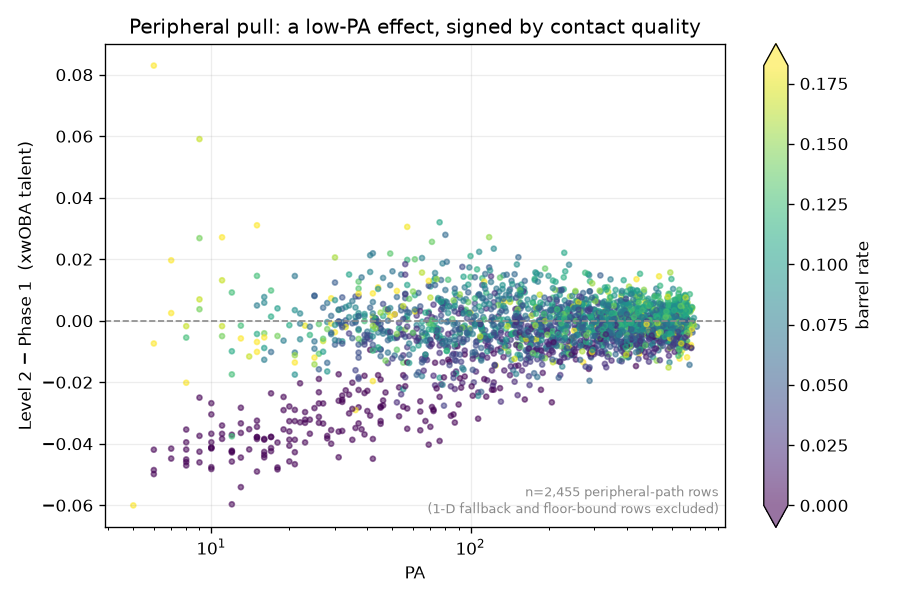

*Level 2 minus Phase 1 per player-season, against PA (log scale) — coloured by barrel rate.*

In [15]:
show_fig("talent2/figures/peripheral_pull.png",
         caption="Level 2 minus Phase 1 per player-season, against PA (log scale) — coloured by barrel rate.")

Same test as §2: does the season-T estimate predict season-(T+1) **actual** wOBA?

In [16]:
def vrow(label, blk):
    return {"population": label, "n": blk["n"],
            "Level 2 r": round(blk["xwoba_talent2"]["r"], 4),
            "Phase 1 r": round(blk["xwoba_talent"]["r"], 4),
            "raw r": round(blk["xwoba_raw"]["r"], 4),
            "Savant r": round(blk["xwoba_savant"]["r"], 4)}
display(pl.DataFrame([vrow("pooled, PA_T >= 100", l2b["pooled_pa100"]),
                      vrow("pooled, PA_T >= 30 (admits low-PA)", l2b["pooled_pa30"])]))
pl.DataFrame([
    {"PA band": r["band"], "n": r["n"],
     "Level 2 r": round(r["xwoba_talent2"]["r"], 3),
     "Phase 1 r": round(r["xwoba_talent"]["r"], 3),
     "gain": round(r["xwoba_talent2"]["r"] - r["xwoba_talent"]["r"], 4),
     "Savant r": round(r["xwoba_savant"]["r"], 3)}
    for r in l2b["by_band"]])

population,n,Level 2 r,Phase 1 r,raw r,Savant r
"""pooled, PA_T >= 100""",1060,0.4908,0.4886,0.4835,0.4908
"""pooled, PA_T >= 30 (admits low…",1173,0.4698,0.4669,0.4454,0.4521


PA band,n,Level 2 r,Phase 1 r,gain,Savant r
"""[30,60)""",50,0.311,0.239,0.0718,0.211
"""[60,100)""",63,0.125,0.088,0.0365,0.128
"""[100,250)""",227,0.293,0.277,0.0166,0.293
"""[250,inf)""",833,0.512,0.512,-0.0,0.523


Pooled, Level 2 beats Phase 1 in both populations — at 100+ PA it now **ties public Savant exactly** (0.4908 vs 0.4908) where Phase 1 was a hair behind, and at PA ≥ 30 it's ahead of Savant by 0.018. But the pooled numbers undersell the mechanism, because they average over a population where most hitters have plenty of PA and the peripherals have nothing to add. The band table is the real result: a clean monotone gradient of **+0.072 at 30–60 PA**, +0.037, +0.017, and then *exactly nothing* at 250+. The help arrives precisely where xwOBA is starving and disappears the moment it isn't.

That's the design's central prediction, and it's the most convincing thing here. One footnote, because it contradicts §2: there I argued the by-band table was *meaningless* for judging shrinkage, since a near-affine estimator can't move Pearson r within a band. That argument still holds for Phase 1. It does **not** hold here — Level 2 isn't affine in raw xwOBA, because it's mixing in an independent signal. (They're also small-n, 50 and 63 hitters in the bottom two bands, so read the gradient, not the third decimal.)

### Now the part where I argue against myself

The pooled gain is **+0.0029**. That is small, and I don't want the by-band gradient to paper over three things that all cut the other way.

In [17]:
pbs = l2b["paired_bootstrap_pa30"]["delta_r"]
sp = l2b["split"]
gain = lambda blk: blk["xwoba_talent2"]["r"] - blk["xwoba_talent"]["r"]
display(pl.DataFrame([{
    "paired bootstrap (5,000 resamples, PA>=30)": f"mean gain {pbs['mean']:+.4f}",
    "95% CI": f"[{pbs['ci95'][0]:+.4f}, {pbs['ci95'][1]:+.4f}]",
    "Level 2 better in": f"{pbs['frac_better']:.1%} of resamples",
}]))
pl.DataFrame([
    {"held-out split": "select (22->23, 23->24) — choices made here", "n": sp["select"]["n"],
     "gain vs Phase 1": f"{gain(sp['select']):+.4f}"},
    {"held-out split": "confirm (24->25) — kept sealed", "n": sp["confirm"]["n"],
     "gain vs Phase 1": f"{gain(sp['confirm']):+.4f}"},
])

"paired bootstrap (5,000 resamples, PA>=30)",95% CI,Level 2 better in
"""mean gain +0.0029""","""[-0.0117, +0.0176]""","""64.1% of resamples"""


held-out split,n,gain vs Phase 1
"""select (22->23, 23->24) — choi…",787,"""+0.0063"""
"""confirm (24->25) — kept sealed""",386,"""-0.0034"""


1. **The confidence interval straddles zero** — [−0.0117, +0.0176], better in 64% of resamples. The point estimate likes Level 2; the sample can't distinguish it from no improvement.
2. **The held-out season reverses the sign.** I scored model choices on 2022→23 and 2023→24 and kept 2024→25 sealed. Select says +0.0063. Confirm says **−0.0034**. The pooled +0.0029 is an average of a win and a loss, and I didn't go back and tune anything to fix that.
3. **The ablations don't agree with each other.** On select the full three-stat model wins, so that's what ships; on confirm the exit-velo-only variant is the only positive one. No variant is consistently ahead.

So: the mechanism does what it was designed to do, in the regime it was designed for, with the sign it predicted, and it costs nothing at high PA. But one season of holdout contradicts it. It ships as an improvement **in expectation**, not a demonstrated one.

(A related trap worth naming: I originally treated "beats on r **and** on calibrated RMSE" as two pieces of evidence. It's one. For a fixed target set the calibrated RMSE is exactly `sd(target)*sqrt(1-r^2)`, so beating on one *implies* beating on the other, always.)

### The test I was most worried about

Here's the failure mode that could have made all of this a mirage. All three stats are computed from **the same batted balls**. A hitter who squares up a few extra balls in 40 PA gets an inflated xwOBA *and* an inflated exit velo *and* an inflated barrel rate, together — not because he's good, but because of the same lucky sample. Regress xwOBA on the peripherals naively and the model can't tell that shared *noise* from shared *talent*: coefficients inflate, talent spread deflates, and you manufacture a beautiful low-PA improvement out of pure luck.

The joint-MVN setup is supposed to be immune, because `S_i` carries the off-diagonal terms that encode exactly that correlation. But "supposed to be" isn't evidence. So: refit with those off-diagonals **zeroed** — deliberately commit the error — and see whether the low-PA gain gets *bigger*. If it does, my gain was the artifact.

In [18]:
tw = l2b["offdiag_tripwire"]
pl.DataFrame([
    {"fit": "proper S_i (shipped)",   "PA>=30 gain vs Phase 1": round(tw["gain_proper"], 4)},
    {"fit": "off-diagonals zeroed",   "PA>=30 gain vs Phase 1": round(tw["gain_zeroed"], 4)},
    {"fit": "--> artifact gap",       "PA>=30 gain vs Phase 1": round(tw["artifact_gap"], 4)},
])

fit,PA>=30 gain vs Phase 1
"""proper S_i (shipped)""",0.0029
"""off-diagonals zeroed""",-0.0101
"""--> artifact gap""",-0.013


**Clean, and not by a small margin.** Zeroing the off-diagonals doesn't inflate the gain — it *destroys* it, leaving a model **worse than Phase 1** (−0.0101). The artifact gap is −0.0130 against an alarm threshold of +0.005. The shared-noise bookkeeping is genuinely load-bearing, and the +0.0029 is not correlated noise being fitted. Had this come back positive I'd have withdrawn the low-PA claim entirely — which is the point of writing the tripwire *before* looking at the answer.

It also fixes the pathology §2 left hanging. Phase 1 measures how noisy a sample is by how much a hitter's outcomes vary from PA to PA. Consider a hitter with **two plate appearances who made two outs**: his outcomes don't vary at all, so the estimator computes variance = zero, concludes the sample is perfectly precise, and reports his true talent as **exactly .000** — the worst hitter in history, stated with total confidence, off two outs.

In [19]:
ff = l2a["floor_fix"]
display(pl.DataFrame([{
    "rows changed by the variance floor": ff["n_floor_bound"],
    "of which Phase-1 variance was exactly 0": ff["n_phase1_se2_exactly_zero"],
    "median PA among them": int(ff["median_pa_floor_bound"]),
    "median move": round(ff["median_abs_diff_floor_bound"], 4),
    "largest move": round(ff["max_abs_diff_floor_bound"], 4),
}]))
pl.DataFrame([{"player": r["player_name"], "season": r["season"], "PA": r["PA"],
               "Phase 1": round(r["phase1"], 3), "Level 2": round(r["level2"], 3),
               "moved": round(r["moved"], 3)} for r in ff["biggest_moves"][:6]])

rows changed by the variance floor,of which Phase-1 variance was exactly 0,median PA among them,median move,largest move
136,7,11,0.0102,0.3085


player,season,PA,Phase 1,Level 2,moved
"""Trevor Rogers""",2025,2,0.0,0.309,0.309
"""Greg Jones""",2025,2,0.0,0.309,0.309
"""Chris Okey""",2023,2,0.0,0.305,0.305
"""Drew Romo""",2025,3,0.0,0.304,0.304
"""Tyler Naquin""",2023,3,0.0,0.3,0.3
"""Billy Hamilton""",2023,2,0.009,0.305,0.296


Trevor Rogers is a **pitcher**. He batted twice in 2025, made two outs, and Phase 1 confidently assigned him a true-talent xwOBA of .000. Level 2 floors the measurement variance so no tiny sample can claim that certainty, and puts him at .309 — league average, the honest answer when you know essentially nothing. 136 rows move and the median move is 0.010, so this is a handful of pathological cases getting sane values, not a rewrite. It does mean the "does it reproduce Phase 1?" gate had to be scored on the 2,500 rows where the two models *should* agree (they correlate at 0.99950) with these 136 reported separately — a gate that passes by excluding the rows you deliberately changed is only honest if you show the rows.

The intervals narrow too, since the peripherals add information about the same underlying talent. I expected that narrowing to be concentrated at low PA. It isn't — it's a fairly uniform 6–9% everywhere, which is coherent with the model but is the least-verified claim in this notebook: at 250+ PA it narrows the interval by 7% while moving the point estimate by *nothing*. Whether those intervals cover at the advertised rate is a coverage test that only gets run in Part 3.

In [20]:
pl.DataFrame([
    {"PA band": r["band"], "n": r["n"],
     "Phase 1 width": round(r["phase1"], 4), "Level 2 width": round(r["level2"], 4),
     "change": f"{100 * (r['level2'] / r['phase1'] - 1):+.1f}%"}
    for r in l2b["interval_width_by_pa"]])

PA band,n,Phase 1 width,Level 2 width,change
"""[30,60)""",239,0.0869,0.0788,"""-9.3%"""
"""[60,100)""",243,0.0787,0.072,"""-8.6%"""
"""[100,250)""",567,0.0667,0.0604,"""-9.4%"""
"""[250,450)""",609,0.0536,0.0498,"""-7.2%"""
"""[450,inf)""",654,0.0466,0.0437,"""-6.1%"""


## Takeaway

Three layers, each fixing the last one's weakness. The band is now a genuine sampling band rather than a statement about the surface. The center is regressed for sample size, which beats the raw number everywhere and edges Savant once low-PA seasons are admitted. And the prior a hitter regresses *toward* is now what his contact quality implies rather than a flat .310, with the help landing exactly where the sample is thin — small in the pooled average, contradicted by one holdout season, and cleared by the one tripwire that could have exposed it as an artifact.

But notice what every one of these estimates has in common with Part 1: they all describe a season that has **already happened**. Even the validation only asks whether a completed season predicts the next completed one. The obvious question a hitter's team actually has in May is different — *given what he's done so far, where does this season end up?* Answering that means changing the object from a descriptor to a **forecast**, with a range that tightens as the games play out. That's Part 3, and it's the part with an actual product in it.

Full write-ups: `results/task_a/NOTES.md`, `results/player_ci/NOTES.md`, `results/talent/NOTES.md`, `results/talent2/NOTES.md`; design in `docs/superpowers/specs/2026-07-19-xwobart-phase2-design-response.md`.

In [21]:
# guard: every number quoted in the prose above, checked against the committed artifacts under
# results/ — fails loudly instead of letting the text silently drift out of date.

# -- 1. the band
assert abs(ta["width_vs_pa_loglog"]["slope"]) < 0.1 and ta["width_r_pa"] > 0     # "flat, if anything faintly increasing"
assert round(ta["savant_in_ci90_fraction"], 2) == 0.94                          # it IS a real band
_s = ci["loglog_slope_width_vs_pa"]["slope"]
assert -0.55 < _s < -0.35                                                       # "near the ideal -0.5"
assert round(ci["corr_bootstrap_width_vs_analytic_se"], 3) == 0.994
_pairs = [(b["pa_mid"], b["median"], m["median"])
          for b, m in zip(ci["bootstrap_width_bin_medians"], ci["model_width_bin_medians"])]
assert round(_pairs[0][1], 3) == 0.102 and round(_pairs[0][2], 3) == 0.056       # 0.102 vs 0.056 at the low bin
assert round(_pairs[0][1] / _pairs[0][2], 1) == 1.8                              # "a factor of 1.8"
assert _pairs[0][0] == 121                                                       # "midpoint 121 PA"
_cross = [i for i in range(1, len(_pairs)) if _pairs[i - 1][1] > _pairs[i - 1][2] and _pairs[i][1] < _pairs[i][2]]
assert len(_cross) == 1 and 450 < _pairs[_cross[0]][0] < 600                     # "cross between 450 and 600 PA"

# -- 2. Phase 1 empirical Bayes
_v = tm["validation"]
_lo, _hi = _v["pooled_lowpa_inclusive"], _v["pooled_pa_min"]
assert round(_lo["xwoba_talent"]["r"], 3) == 0.467 and round(_lo["xwoba_savant"]["r"], 3) == 0.452
assert round(_hi["xwoba_talent"]["r"], 3) == 0.489 and round(_hi["xwoba_savant"]["r"], 3) == 0.491
_taus = sorted(round(r["tau"], 4) for r in tm["per_season"])
assert _taus[0] == 0.0307 and _taus[-1] == 0.0323                                # the tau range quoted in section 3

# -- 3. Level 2
_gains = [round(gain(r), 3) for r in l2b["by_band"]]
assert _gains[0] == 0.072 and abs(_gains[-1]) < 0.005                            # "+0.072 at 30-60 ... nothing at 250+"
assert _gains == sorted(_gains, reverse=True)                                    # "a clean monotone gradient"
assert [r["n"] for r in l2b["by_band"]][:2] == [50, 63]                          # "50 and 63 hitters in the bottom two bands"
assert round(gain(l2b["pooled_pa30"]), 4) == 0.0029                              # "the pooled gain is +0.0029"
assert round(l2b["pooled_pa100"]["xwoba_talent2"]["r"], 4) == round(l2b["pooled_pa100"]["xwoba_savant"]["r"], 4) == 0.4908
assert round(l2b["pooled_pa30"]["xwoba_talent2"]["r"] - l2b["pooled_pa30"]["xwoba_savant"]["r"], 3) == 0.018
assert pbs["ci95"][0] < 0 < pbs["ci95"][1] and round(pbs["frac_better"], 2) == 0.64
assert [round(x, 4) for x in pbs["ci95"]] == [-0.0117, 0.0176]
assert round(gain(sp["select"]), 4) == 0.0063 and round(gain(sp["confirm"]), 4) == -0.0034
_ab = {k: v for k, v in l2b["ablations"].items() if k != "note"}
assert gain(_ab["full_3d"]["select"]) == max(gain(v["select"]) for v in _ab.values())     # full 3d wins on select
assert [k for k in _ab if gain(_ab[k]["confirm"]) > 0] == ["xwoba+avg_ev"]                 # EV-only is the lone positive on confirm
_corr = l2b["sigma_talent_corr"]
assert round(_corr[0][1], 2) == 0.78 and round(_corr[0][2], 2) == 0.71
assert round(float(np.sqrt(H["Sigma"][0][0])), 4) == 0.0312
assert round(tw["gain_zeroed"], 4) == -0.0101 and round(tw["artifact_gap"], 4) == -0.013
assert tw["artifact_gap"] < 0.005                                                # below the alarm threshold
assert l2a["floor_fix"]["n_floor_bound"] == 136
assert round(l2a["floor_fix"]["median_abs_diff_floor_bound"], 3) == 0.010
assert round(l2a["floor_fix"]["corr_comparable"], 5) == 0.99950                  # "correlate at 0.99950"
assert all(-0.10 < r["level2"] / r["phase1"] - 1 < -0.05 for r in l2b["interval_width_by_pa"])  # "uniform 6-9%"

print("prose numbers still match the artifacts")

prose numbers still match the artifacts
